# Step 4: Black-Litterman Portfolio Optimization

XGBoost Walk-Forward에서 산출한 **Q** (기대수익률 뷰)와 **Ω** (뷰 불확실성)를 사용하여
Black-Litterman 모델로 최적 포트폴리오 비중을 구합니다.

파이프라인:
1. **Prior**: Risk-Parity(ERC) 가중치 → 내재 균형 수익률 π = δΣw_rp
2. **Likelihood**: XGBoost Q, Ω (diagonal)
3. **Posterior**: μ_BL, Σ_BL via Black-Litterman
4. **Allocation**: MVO (투자자 성향별 γ), τ grid-search로 최적 τ 선택
5. **Backtest**: 거래비용(30bps), 성과지표, 시각화


## 1. Imports & 설정

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
from math import sqrt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# ── 공통 설정 ──────────────────────────────────────────────────────────────
IS_DAYS      = 252   # In-Sample 기간 (영업일)
EMBARGO_DAYS = 21    # IS·OOS 사이 엠바고 (영업일)
OOS_DAYS     = 21    # Out-of-Sample 기간 (영업일)

DELTA  = 2.5         # 시장 위험 회피 계수 (Risk-Parity Prior용)
W_MAX  = 0.30        # 단일 자산 최대 비중
TC_BPS = 30          # 거래비용 (왕복, basis points)
TC     = TC_BPS / 10_000

GAMMAS = {
    '공격형' : 1.0,
    '중립형' : 3.0,
    '보수형' : 8.0,
}

DATA_DIR  = Path('data')
STEP3_DIR = Path('outputs/step3')   # Q, Omega 읽기용
OUT_DIR   = Path('outputs/step4')   # Step4 결과 저장용
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. 데이터 로드

Step3에서 저장한 Q (기대수익률 뷰)와 Ω (뷰 불확실성), 그리고 일별 수익률을 로드합니다.


In [29]:
# ── Q & Omega 로드 (Step3 walk-forward 출력) ───────────────────────────
Q_df     = pd.read_parquet(STEP3_DIR / 'Q_xgb.parquet')     # index=date, columns=ticker
Omega_df = pd.read_parquet(STEP3_DIR / 'Omega_xgb.parquet') # index=date, columns=ticker

# 단위 통일: Step3 Q는 21일 수익률, BL prior π는 연율화 기준 → 스케일 맞춤
Q_df     = Q_df     * (252 / 21)
Omega_df = Omega_df * (252 / 21) ** 2  # 분산이므로 제곱

# ── 패널 데이터 (일별 수익률 재구성용) ────────────────────────────────────
panel_df = pd.read_csv(DATA_DIR / 'df_panel.csv',
                        parse_dates=['Date'], index_col=['Date', 'Ticker'])

# 일별 수익률 피벗: index=date, columns=ticker
ret_pivot = (panel_df['ret']
             .unstack('Ticker')
             .sort_index())

tickers = Q_df.columns.tolist()
ret_pivot = ret_pivot[tickers]  # 컬럼 순서 맞춤

print(f'Q_df      : {Q_df.shape}')
print(f'Omega_df  : {Omega_df.shape}')
print(f'ret_pivot : {ret_pivot.shape}')
print(f'tickers   : {tickers}')
print(f'date range: {ret_pivot.index.min()} ~ {ret_pivot.index.max()}')

Q_df      : (2058, 22)
Omega_df  : (2058, 22)
ret_pivot : (2346, 22)
tickers   : ['AGG', 'DBC', 'EEM', 'EFA', 'GLD', 'IWM', 'QQQ', 'SHY', 'SPY', 'TIP', 'TLT', 'VOX', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
date range: 2017-01-04 00:00:00 ~ 2025-12-31 00:00:00


## 3. 헬퍼 함수

In [30]:
# ── 3-1. Ledoit-Wolf 공분산 추정 ─────────────────────────────────────────
def estimate_covariance(ret_df: pd.DataFrame, annualize: bool = True) -> np.ndarray:
    """
    Ledoit-Wolf shrinkage로 안정적인 공분산 행렬 추정.
    annualize=True면 일별 공분산 * 252 반환.
    """
    clean = ret_df.ffill().dropna(how='all').fillna(0)
    lw = LedoitWolf().fit(clean.values)
    cov = lw.covariance_
    return cov * 252 if annualize else cov


# ── 3-2. tau 초기값 & 그리드 ─────────────────────────────────────────────
def compute_tau_init(omega_vec: np.ndarray, cov_ann: np.ndarray) -> float:
    """
    tau_init = mean(Omega) / mean(diag(Sigma))
    직관: 뷰 불확실성이 자산 분산 대비 얼마나 큰지 비율
    """
    return float(np.mean(omega_vec) / np.mean(np.diag(cov_ann)))


def compute_tau_grid(tau_init: float) -> list:
    """
    project_design_v3 기준:
      {0.5t, 0.75t, t, 1.25t, 1.5t} + 고정 그리드 [0.005, 0.01, 0.025, 0.05, 0.1]
    중복 제거 후 정렬 반환.
    """
    relative = [0.50 * tau_init, 0.75 * tau_init,
                tau_init,
                1.25 * tau_init, 1.50 * tau_init]
    fixed    = [0.005, 0.01, 0.025, 0.05, 0.1]
    combined = sorted(set([round(v, 6) for v in relative + fixed]))
    return combined


# ── 3-3. 포트폴리오 성과지표 ─────────────────────────────────────────────
def portfolio_metrics(rets: pd.Series, rf: float = 0.0) -> dict:
    """
    rets: 일별 포트폴리오 수익률 Series
    반환: Annual Return, Annual Vol, Sharpe, Max Drawdown
    """
    ann_ret = rets.mean() * 252
    ann_vol = rets.std()  * sqrt(252)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 1e-12 else np.nan
    cum     = (1 + rets).cumprod()
    roll_max = cum.cummax()
    dd      = (cum - roll_max) / roll_max
    mdd     = dd.min()
    return {'Ann.Return': ann_ret, 'Ann.Vol': ann_vol,
            'Sharpe': sharpe, 'MDD': mdd}


# ── 3-4. 거래비용 적용 ────────────────────────────────────────────────────
def apply_transaction_cost(w_new: np.ndarray, w_prev: np.ndarray,
                            tc: float = TC) -> float:
    """
    왕복 거래비용 = sum(|w_new - w_prev|) * tc
    """
    return np.sum(np.abs(w_new - w_prev)) * tc


## 4. Black-Litterman + MVO 함수

In [31]:
# ── 4-1. Risk Parity (ERC) 가중치 ───────────────────────────────────────
def get_risk_parity_weights(cov_matrix: np.ndarray) -> np.ndarray:
    """
    Equal Risk Contribution (ERC) 최적화.
    목표: 각 자산의 위험 기여도가 포트폴리오 분산의 1/N 이 되도록 최소화.
    """
    n = cov_matrix.shape[0]

    def objective(w):
        port_var   = w @ cov_matrix @ w
        rc         = w * (cov_matrix @ w)        # Risk Contribution vector
        target     = port_var / n
        return np.sum((rc - target) ** 2) * 1e6  # 스케일 업으로 최적화 안정성 확보

    w0          = np.ones(n) / n
    bounds      = [(0.0, 1.0)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    res = minimize(objective, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    if not res.success:
        print('[WARN] Risk Parity optimization did not converge — falling back to 1/N')
        return w0
    return res.x


# ── 4-2. Prior 내재 균형 수익률 ───────────────────────────────────────────
def get_bl_prior(cov_matrix: np.ndarray, w_prior: np.ndarray,
                 delta: float = DELTA) -> np.ndarray:
    """
    π = δ * Σ * w_prior
    """
    return delta * (cov_matrix @ w_prior)


# ── 4-3. Black-Litterman Posterior ────────────────────────────────────────
def get_black_litterman(Q: np.ndarray, Omega: np.ndarray,
                         cov_matrix: np.ndarray, pi: np.ndarray,
                         tau: float):
    """
    절대적 뷰 (P = I) 가정.
    μ_BL = [(τΣ)^{-1} + Ω^{-1}]^{-1} [(τΣ)^{-1}π + Ω^{-1}Q]
    Σ_BL = Σ + [(τΣ)^{-1} + Ω^{-1}]^{-1}
    """
    inv_tau_cov = np.linalg.inv(tau * cov_matrix)
    inv_omega   = np.linalg.inv(Omega)

    M      = np.linalg.inv(inv_tau_cov + inv_omega)   # posterior precision^{-1}
    mu_bl  = M @ (inv_tau_cov @ pi + inv_omega @ Q)
    cov_bl = cov_matrix + M
    return mu_bl, cov_bl


# ── 4-4. MVO (투자자 성향별) ─────────────────────────────────────────────
def mvo_optimize(mu: np.ndarray, cov_matrix: np.ndarray,
                 gamma: float, w_max: float = W_MAX) -> np.ndarray:
    """
    max  w'μ - (γ/2) w'Σw
    s.t. sum(w) = 1,  0 ≤ w_i ≤ w_max
    """
    n  = len(mu)
    w0 = np.ones(n) / n

    def objective(w):
        return -(w @ mu - (gamma / 2) * (w @ cov_matrix @ w))

    bounds      = [(0.0, w_max)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    res = minimize(objective, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    if not res.success:
        return w0
    return res.x


## 5. Walk-Forward 윈도우 생성

Step3와 동일한 윈도우 구조를 사용합니다.  
`is_dates` → Ledoit-Wolf 공분산 추정  
`val_dates` → τ 그리드 서치 검증  
`oos_dates` → 실제 포트폴리오 수익률 계산


In [32]:
def generate_windows(all_dates: pd.DatetimeIndex,
                      is_days:      int = IS_DAYS,
                      embargo_days: int = EMBARGO_DAYS,
                      oos_days:     int = OOS_DAYS) -> list:
    """
    Step3와 동일한 슬라이딩 윈도우(고정 IS 크기) 생성.
    is_dates   : IS 구간 날짜 배열 (항상 is_days 크기로 고정)
    val_dates  : IS 마지막 oos_days 일 (tau grid search 검증)
    oos_dates  : OOS 구간 날짜 배열
    """
    windows = []
    n = len(all_dates)
    i = 0
    while True:
        oos_end = i + is_days + embargo_days + oos_days
        if oos_end > n:
            break
        is_d  = all_dates[i : i + is_days]
        val_d = all_dates[i + is_days - oos_days : i + is_days]  # IS 마지막 21일
        oos_d = all_dates[i + is_days + embargo_days : oos_end]
        windows.append({'is_dates': is_d, 'val_dates': val_d, 'oos_dates': oos_d})
        i += oos_days
    return windows


# Q_df에 데이터가 있는 날짜 기준으로 윈도우 생성
q_dates   = Q_df.index.sort_values()
all_dates = ret_pivot.index.sort_values()

windows = generate_windows(all_dates, IS_DAYS, EMBARGO_DAYS, OOS_DAYS)
print(f'총 윈도우 수: {len(windows)}')
print(f'첫 IS : {windows[0]["is_dates"][0].date()} ~ {windows[0]["is_dates"][-1].date()}')
print(f'첫 OOS: {windows[0]["oos_dates"][0].date()} ~ {windows[0]["oos_dates"][-1].date()}')

총 윈도우 수: 98
첫 IS : 2017-01-04 ~ 2017-12-21
첫 OOS: 2018-01-22 ~ 2018-02-19


## 6. Walk-Forward BL + MVO 루프

In [33]:
# 결과 저장 컨테이너
records      = {gname: [] for gname in GAMMAS}  # 일별 포트폴리오 수익률
weight_hist  = {gname: [] for gname in GAMMAS}  # 리밸런싱 비중 이력
tau_hist     = []                                 # 선택된 tau 이력
oos_date_hist = []                                # OOS 첫 날짜 (리밸런싱일)

# 이전 비중 초기화 (거래비용 계산용)
prev_w = {gname: np.ones(len(tickers)) / len(tickers) for gname in GAMMAS}

for window in tqdm(windows, desc='BL Walk-Forward'):
    is_d   = pd.DatetimeIndex(window['is_dates'])
    val_d  = pd.DatetimeIndex(window['val_dates'])
    oos_d  = pd.DatetimeIndex(window['oos_dates'])

    # ── IS 구간 수익률 & 공분산 ────────────────────────────────────────────
    is_ret  = ret_pivot.loc[ret_pivot.index.isin(is_d),  tickers]
    val_ret = ret_pivot.loc[ret_pivot.index.isin(val_d), tickers]
    oos_ret = ret_pivot.loc[ret_pivot.index.isin(oos_d), tickers]

    if is_ret.shape[0] < IS_DAYS // 2:  # 데이터 부족 시 스킵
        continue

    cov_ann = estimate_covariance(is_ret, annualize=True)

    # ── Q, Omega: OOS 구간에 겹치는 Q_df 날짜 평균 ─────────────────────────
    oos_q_idx = q_dates[q_dates.isin(oos_d)]
    if len(oos_q_idx) == 0:
        # OOS 구간에 Q가 없으면 직전 가장 가까운 Q 사용
        past_q = q_dates[q_dates < oos_d[0]]
        if len(past_q) == 0:
            continue
        oos_q_idx = past_q[[-1]]

    Q_vec     = Q_df.loc[oos_q_idx, tickers].mean().fillna(0.0).values
    Omega_vec = Omega_df.loc[oos_q_idx, tickers].mean().fillna(1e-4).values
    Omega_mat = np.diag(np.maximum(Omega_vec, 1e-8))

    # ── Risk Parity Prior ─────────────────────────────────────────────────
    w_rp = get_risk_parity_weights(cov_ann)
    pi   = get_bl_prior(cov_ann, w_rp, delta=DELTA)

    # ── tau Grid Search (검증: val 구간 실제 포트폴리오 Sharpe) ───────────
    tau_init    = compute_tau_init(Omega_vec, cov_ann)
    tau_grid    = compute_tau_grid(tau_init)

    val_ret_mat = val_ret.fillna(0).values   # (21일, n_assets)
    best_tau    = tau_grid[0]
    best_sharpe = -np.inf

    for tau in tau_grid:
        try:
            mu_tmp, cov_tmp = get_black_litterman(Q_vec, Omega_mat, cov_ann, pi, tau)
            w_tmp      = mvo_optimize(mu_tmp, cov_tmp, gamma=3.0, w_max=W_MAX)
            port_daily = val_ret_mat @ w_tmp          # 실제 일별 수익률
            p_vol      = port_daily.std() * sqrt(252)
            p_ret      = port_daily.mean() * 252
            sharpe     = p_ret / p_vol if p_vol > 1e-12 else 0.0
        except np.linalg.LinAlgError:
            continue
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_tau    = tau

    tau_hist.append(best_tau)
    oos_date_hist.append(oos_d[0])

    # ── 성향별 BL + MVO → OOS 수익률 기록 ───────────────────────────────
    for gname, gamma in GAMMAS.items():
        try:
            mu_bl, cov_bl = get_black_litterman(Q_vec, Omega_mat, cov_ann, pi, best_tau)
            w_opt = mvo_optimize(mu_bl, cov_bl, gamma=gamma, w_max=W_MAX)
        except np.linalg.LinAlgError:
            w_opt = np.ones(len(tickers)) / len(tickers)

        # 거래비용 차감
        tc_cost = apply_transaction_cost(w_opt, prev_w[gname])
        prev_w[gname] = w_opt.copy()

        weight_hist[gname].append({'date': oos_d[0], 'weights': w_opt})

        # OOS 일별 수익률
        daily_rets = oos_ret.fillna(0) @ w_opt
        # 거래비용은 첫 날에만 차감
        if len(daily_rets) > 0:
            daily_rets.iloc[0] -= tc_cost

        for dt, r in daily_rets.items():
            records[gname].append({'date': dt, 'ret': r})

print('Walk-Forward 완료')
print(f'기록된 OOS 날짜 수: {len(records["중립형"])}')

BL Walk-Forward:   0%|          | 0/98 [00:00<?, ?it/s]

Walk-Forward 완료
기록된 OOS 날짜 수: 2058


## 7. OOS 성과 분석

In [34]:
# ── 성향별 일별 수익률 Series 생성 ──────────────────────────────────────
ret_series = {}
for gname in GAMMAS:
    df = pd.DataFrame(records[gname]).set_index('date').sort_index()
    ret_series[gname] = df['ret']

# ── 벤치마크: 동일 비중 (1/N) ─────────────────────────────────────────────
# 첫 번째 OOS 시작 ~ 마지막 OOS 종료 기간 동일 비중 수익률
bench_start = min(s.index.min() for s in ret_series.values())
bench_end   = max(s.index.max() for s in ret_series.values())
bench_ret   = (ret_pivot
               .loc[bench_start:bench_end, tickers]
               .mean(axis=1))          # 동일비중 일별 수익률

# ── 성과지표 테이블 ───────────────────────────────────────────────────────
rows = []
for gname, s in ret_series.items():
    m = portfolio_metrics(s)
    m['Strategy'] = f'BL-{gname}'
    rows.append(m)
m_bench = portfolio_metrics(bench_ret)
m_bench['Strategy'] = '1/N Benchmark'
rows.append(m_bench)

perf_df = (pd.DataFrame(rows)
           .set_index('Strategy')
           [['Ann.Return', 'Ann.Vol', 'Sharpe', 'MDD']])
perf_df[['Ann.Return', 'Ann.Vol', 'MDD']] *= 100

print(perf_df.round(2).to_string())


               Ann.Return  Ann.Vol  Sharpe    MDD
Strategy                                         
BL-공격형              -6.57    17.53   -0.37 -58.05
BL-중립형              -4.36    11.91   -0.37 -41.42
BL-보수형              -2.20     8.58   -0.26 -26.63
1/N Benchmark        7.82    13.85    0.56 -29.39


## 8. 시각화

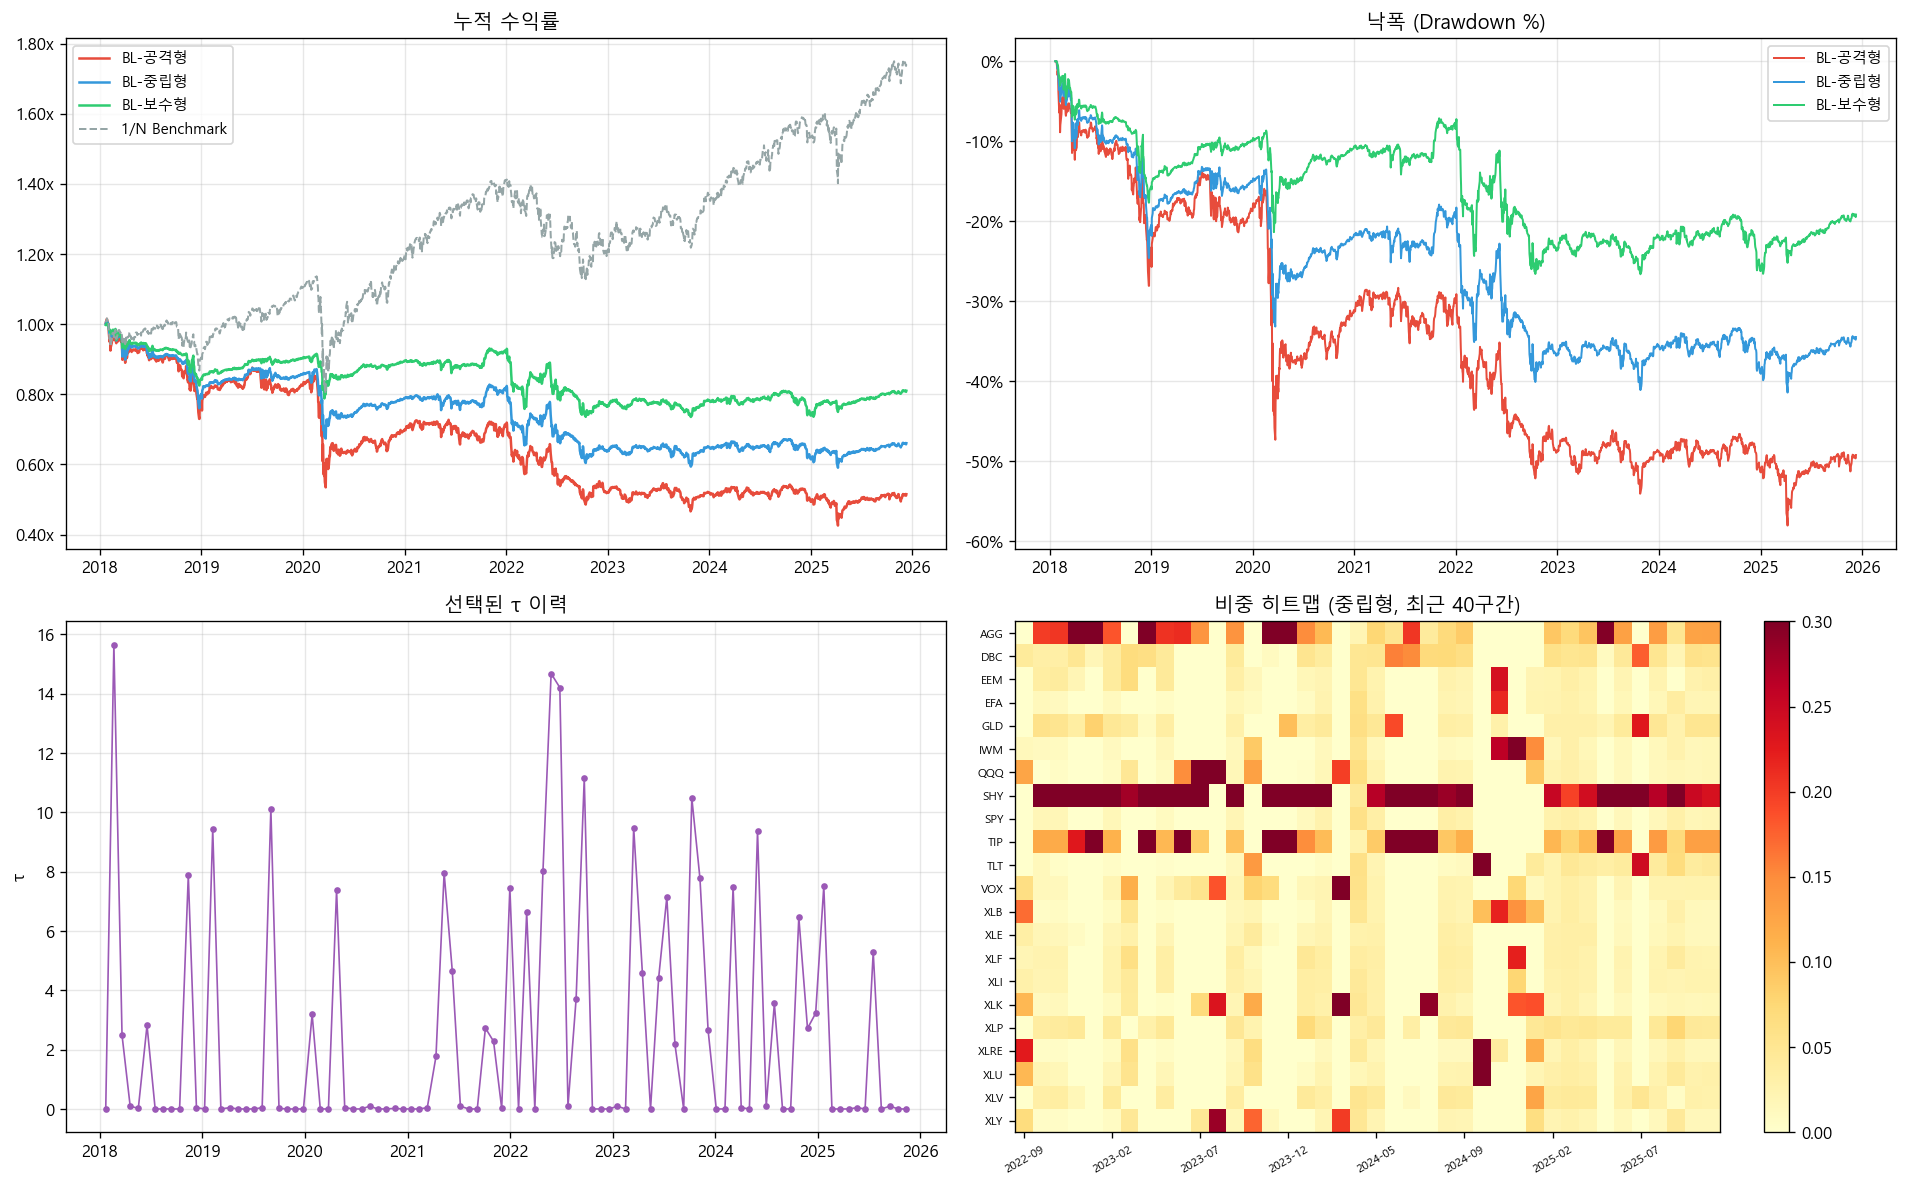

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 8-1. 누적 수익률 ──────────────────────────────────────────────────────
ax1 = axes[0, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
for (gname, s), color in zip(ret_series.items(), colors):
    cum = (1 + s).cumprod()
    ax1.plot(cum.index, cum.values, label=f'BL-{gname}', color=color, lw=1.5)
bench_cum = (1 + bench_ret.reindex(ret_series['중립형'].index).fillna(0)).cumprod()
ax1.plot(bench_cum.index, bench_cum.values,
         label='1/N Benchmark', color='#95a5a6', lw=1.2, ls='--')
ax1.set_title('누적 수익률')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax1.grid(True, alpha=0.3)

# ── 8-2. 낙폭 (Drawdown) ─────────────────────────────────────────────────
ax2 = axes[0, 1]
for (gname, s), color in zip(ret_series.items(), colors):
    cum = (1 + s).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax2.plot(dd.index, dd.values, label=f'BL-{gname}', color=color, lw=1.2)
ax2.set_title('낙폭 (Drawdown %)')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.grid(True, alpha=0.3)

# ── 8-3. tau 선택 이력 ────────────────────────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(oos_date_hist, tau_hist, marker='o', ms=3, lw=1, color='#9b59b6')
ax3.set_title('선택된 τ 이력')
ax3.set_ylabel('τ')
ax3.grid(True, alpha=0.3)

# ── 8-4. 최근 비중 히트맵 (중립형) ───────────────────────────────────────
ax4 = axes[1, 1]
w_records = weight_hist['중립형']
if w_records:
    w_mat = np.array([r['weights'] for r in w_records[-40:]])
    w_dates = [r['date'].strftime('%Y-%m') for r in w_records[-40:]]
    im = ax4.imshow(w_mat.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=W_MAX)
    ax4.set_yticks(range(len(tickers)))
    ax4.set_yticklabels(tickers, fontsize=7)
    ax4.set_xticks(range(0, len(w_dates), max(1, len(w_dates)//8)))
    ax4.set_xticklabels(
        [w_dates[i] for i in range(0, len(w_dates), max(1, len(w_dates)//8))],
        rotation=30, fontsize=7)
    ax4.set_title('비중 히트맵 (중립형, 최근 40구간)')
    plt.colorbar(im, ax=ax4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_portfolio_summary.png', dpi=150)
plt.show()


## 9. 결과 저장

In [ ]:
# ── 성과 테이블 저장 ──────────────────────────────────────────────────────
perf_df.to_csv(OUT_DIR / 'bl_performance.csv')
print('성과 테이블 저장:', OUT_DIR / 'bl_performance.csv')

# ── 성향별 누적 수익률 저장 ────────────────────────────────────────────────
cum_df = pd.concat(
    {gname: (1 + s).cumprod() for gname, s in ret_series.items()},
    axis=1
)
cum_df.to_csv(OUT_DIR / 'bl_cumulative_returns.csv')
print('누적 수익률 저장:', OUT_DIR / 'bl_cumulative_returns.csv')

# ── 비중 이력 저장 (중립형 예시) ───────────────────────────────────────────
w_df_list = []
for gname in GAMMAS:
    for rec in weight_hist[gname]:
        row = {'strategy': gname, 'date': rec['date']}
        row.update(dict(zip(tickers, rec['weights'])))
        w_df_list.append(row)
w_df = pd.DataFrame(w_df_list).set_index(['strategy', 'date'])
w_df.to_csv(OUT_DIR / 'bl_weights.csv')
print('비중 이력 저장 :', OUT_DIR / 'bl_weights.csv')

성과 테이블 저장: outputs\step4\bl_performance.csv
누적 수익률 저장: outputs\step4\bl_cumulative_returns.csv
비중 이력 저장 : outputs\step4\bl_weights.csv
